# Downwinding Workflow Example 4:
- An irrigular domain and a pre-defined river network to be used for the DEM processing
- Calculating slopes with a downwinding approach to be consistent with ParFlow's OverlandFlow boundary conditon. 
- This requires three inputs: (1) a DEM,  (2) a river mask and (3) a watershed mask

 This example usese the test domain from Condon and Maxwell (2019) (https://doi.org/10.1016/j.cageo.2019.01.020)
 the datasets for this domain are provided with the PriorityFlow R package
 to use your own datasets you should have a DEM and mask files formatted as a matrices
 with [i,j] corresponding to the x and y axes of the domain 
 (i.e. DEM[0,0] is the lower left corner of the domain and DEM[nx,ny] is the upper right)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from priority_flow import (
    init_queue,
    d4_traverse_b,
    load_dem,
    load_river_mask,
    load_watershed_mask,
    get_border,
    drainage_area,
    calc_subbasins,
    slope_calc_upwind,
    stream_traverse,
    find_orphan,
)

from parflow.tools.io import read_pfb, write_pfb

In [2]:
# -------------------------------------------------------------------------
# Settings (mirroring the R script)
# -------------------------------------------------------------------------
# DEM processing
ep = 0.01  # epsilon value applied to flat cells

# Slope scaling
maxslope = 0.5  # maximum slope; set to -1 to disable
minslope = 1e-5  # minimum slope; set to -1 to disable
scale = 0.1  # max ratio of secondary to primary flow direction (secondaryTH)

# River and subbasin size for slope calculations
sub_th = 100  # area threshold (cells) for subbasin delineation
riv_th = sub_th  # optional: threshold for river mask for slope processing
riv_method = 3  # 0: none, 1: scale river secondary, 2: basin mean, 3: reach mean
mrg_th = 10  # merge threshold for small subbasins

# Grid dimensions for slopes
dx = 1000.0
dy = 1000.0

# Run name for outputs
runname = "Test"

# -------------------------------------------------------------------------
# Load DEM, river mask, and watershed mask
# -------------------------------------------------------------------------
DEM = load_dem()
river_mask = load_river_mask()
watershed_mask = load_watershed_mask()
nx, ny = DEM.shape
print(f"Domain size: nx={nx}, ny={ny}")

Domain size: nx=172, ny=215


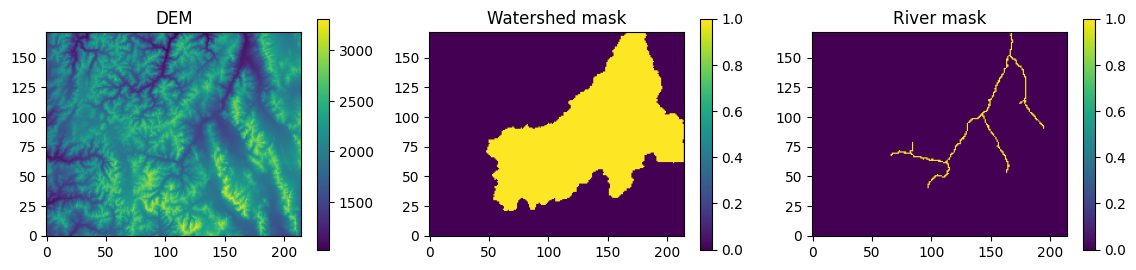

In [3]:
# Plot the inputs:
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
im0 = axes[0].imshow(DEM, cmap='viridis', origin='lower')
axes[0].set_title("DEM")
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(watershed_mask, cmap='viridis', origin='lower')
axes[1].set_title("Watershed mask")
plt.colorbar(im1, ax=axes[1])
im1 = axes[2].imshow(river_mask, cmap='viridis', origin='lower')
axes[2].set_title("River mask")
plt.colorbar(im1, ax=axes[2])

In [4]:
# Process the DEM:
#1. Initialize the queue with river cells that fall on the border
#2. Traverse the stream network filling sinks and stair stepping around D8 neigbhors
#3. Look for orphan branches and continue processing until they are all connected
#4. Use the processed river cells as the intialize a new queue
#5. process hillslopes from there

#1.initialize the queue with river cells that fall on the border
init = init_queue(
    DEM,
    initmask=river_mask,
    domainmask=watershed_mask,
)

No border provided, setting border using domain mask


In [5]:
#2.take a first pass at traversing the streams
trav1 = stream_traverse(
    dem=DEM,
    mask=river_mask,
    queue=init["queue"].copy(),
    marked=init["marked"].copy(),
    basins=init["basins"].copy(),
    printstep=False,
    epsilon=ep,
)
first_pass_pct = (
    np.sum(trav1["marked"] * river_mask) / np.sum(river_mask) * 100.0
    if np.sum(river_mask) > 0
    else 0.0
)
print(f"First Pass: {first_pass_pct:.1f} % cells processed")

First Pass: 100.0 % cells processed


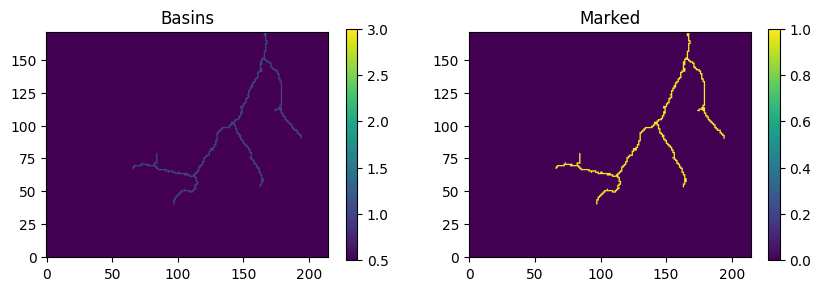

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
im0 = axes[0].imshow(trav1['basins'], vmin=0.5, vmax=np.nanmax(trav1['basins']), cmap='viridis', origin='lower')
axes[0].set_title("Basins")
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(trav1['marked'], cmap='viridis', origin='lower')
axes[1].set_title("Marked")
plt.colorbar(im1, ax=axes[1])
plt.show()

In [7]:
#3. look for 'orphaned' branches and continue traversing until they are all connected
# orphaned branches are portions of the river network that are connected diagonally (i.e. without any d4 neighbors)

norphan = 1
lap = 1
while norphan > 0:
    orphan = find_orphan(
        dem=trav1["dem"],
        mask=river_mask,
        marked=trav1["marked"],
    )
    norphan = int(orphan["norphan"])
    print(f"lap {lap}: {norphan} orphans found")

    if norphan > 0:
        trav2 = stream_traverse(
            dem=trav1["dem"],
            mask=river_mask,
            queue=orphan["queue"],
            marked=trav1["marked"],
            step=trav1["step"],
            direction=trav1["direction"],
            basins=trav1["basins"],
            printstep=False,
            epsilon=ep,
        )
        trav1 = trav2
        lap += 1
    else:
        print("Done! No orphan branches found")

final_pass_pct = (
    np.sum(trav1["marked"] * river_mask) / np.sum(river_mask) * 100.0
    if np.sum(river_mask) > 0
    else 0.0
)
print(f"Final pass: {final_pass_pct:.1f} % cells processed")

No Orphans Found
lap 1: 0 orphans found
Done! No orphan branches found
Final pass: 100.0 % cells processed


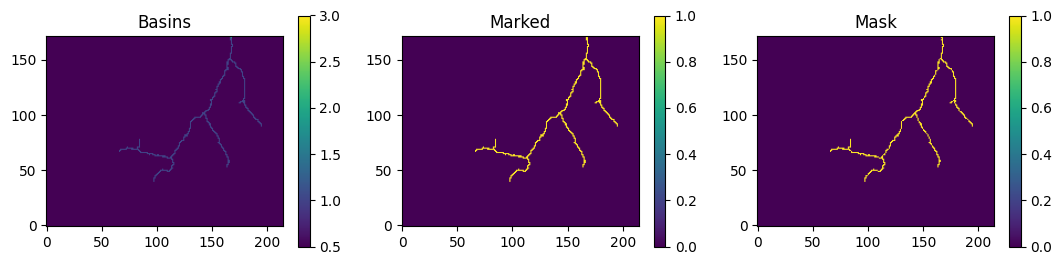

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
im0 = axes[0].imshow(trav1['basins'], vmin=0.5, vmax=np.nanmax(trav1['basins']), cmap='viridis', origin='lower')
axes[0].set_title("Basins")
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(trav1['marked'], cmap='viridis', origin='lower')
axes[1].set_title("Marked")
plt.colorbar(im1, ax=axes[1])
im2 = axes[2].imshow(trav1['mask'], cmap='viridis', origin='lower')
axes[2].set_title("Mask")
plt.colorbar(im1, ax=axes[2])
plt.show()

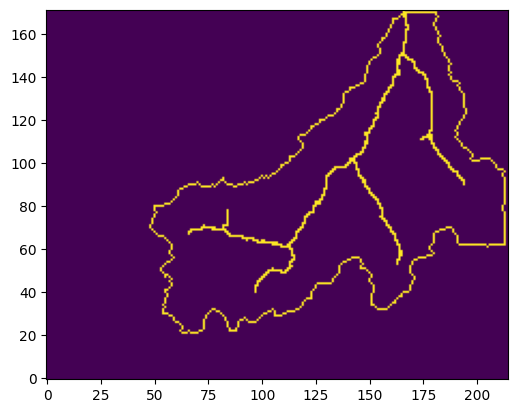

In [9]:
# 4.initialize the queue with every cell on the processed river boundary
# to do this use the marked rivers from the last step plus the edge cells
# as the boundary and the mask

border_t = get_border(watershed_mask)
riv_border = border_t + trav1["marked"]
riv_border[riv_border > 1] = 1

plt.imshow(riv_border, cmap='viridis', origin='lower')

In [10]:
init2 = init_queue(trav1["dem"], border=riv_border)

No init mask provided all border cells will be added to queue
No domain mask provided using entire domain


In [11]:
# 5.process all the cells off the river usins the river as the boundary
trav_hs = d4_traverse_b(
    dem=trav1["dem"],
    queue=init2["queue"].copy(),
    marked=init2["marked"].copy(),
    direction=trav1["direction"].copy(),
    basins=trav1["basins"].copy(),
    step=trav1["step"].copy(),
    epsilon=ep,
    mask=watershed_mask,
)

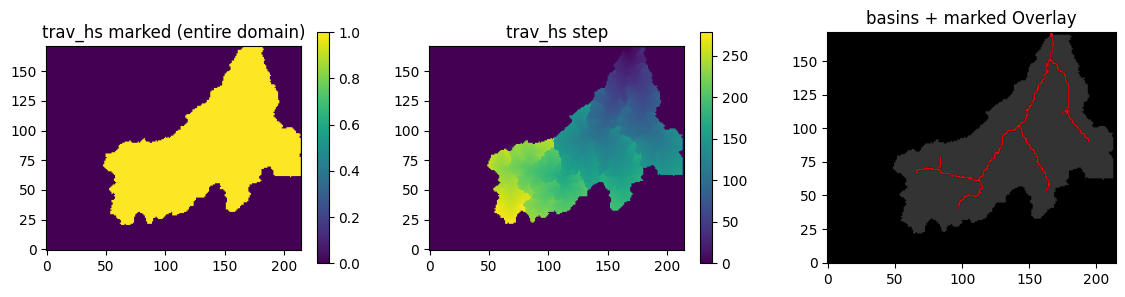

In [12]:
from matplotlib.colors import LinearSegmentedColormap

# Extract arrays
marked_HS = trav_hs['marked']
step = trav_hs['step']
basins = trav_hs['basins']
marked_overlay = trav1['marked']

# Create white → red colormap
maskcol = LinearSegmentedColormap.from_list("maskcol", ["white", "red"])
fig, axes = plt.subplots(1, 3, figsize=(14, 3))

im0 = axes[0].imshow(marked_HS, origin='lower', cmap='viridis')
axes[0].set_title("trav_hs marked (entire domain)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(step, origin='lower', cmap='viridis')
axes[1].set_title("trav_hs step")
plt.colorbar(im1, ax=axes[1])

axes[2].imshow(basins, vmin=0.5, vmax=np.nanmax(basins), cmap='gray', origin='lower')
overlay = marked_overlay.copy()
overlay[overlay == 0] = np.nan  # make zeros transparent
axes[2].imshow(overlay, vmin=0.5, vmax=1, cmap=maskcol, origin='lower', alpha=0.9)
axes[2].set_title("basins + marked Overlay")
plt.show()

## Calculate the slopes
Note this step also fixes the directions of the borders because
directions are not provided when the queue is initialized

### Option 1: just calcualte the slopes for the entire domain with no distinction between river and hillslope cells
In this example secondary slope scaling is turned on and the secondary
Slopes in the secondary direction are set to a maximum of 0.1*primary flow direction
To calculate only slopes in the primary flow direction set the secondaryTH to 0
Additionally primary slopes are limited by min slope and max slope thresholds

In [14]:
slopes_uw = slope_calc_upwind(
    dem=trav_hs["dem"].copy(),
    mask=watershed_mask.copy(),
    direction=trav_hs["direction"].copy(),
    dx=dx,
    dy=dy,
    secondary_th=scale,
    maxslope=maxslope,
    minslope=minslope,
)

upwinding slopes
Limiting slopes to maximum absolute value of 0.5
Limiting the ratio of secondary to primary slopes 0.1
After processing: 0 Flat cells left
Limiting slopes to minimum 1e-05


### Option 2: If you would like to handle river cells differently from the rest of the domain

In [15]:
# Calculate the drainage area
area = drainage_area(
    trav_hs["direction"].copy(),
    printflag=False,
)

In [16]:
subbasin = calc_subbasins(
    trav_hs["direction"].copy(),
    area=area,
    mask=watershed_mask.copy(),
    riv_th=sub_th,
    merge_th=mrg_th,
)

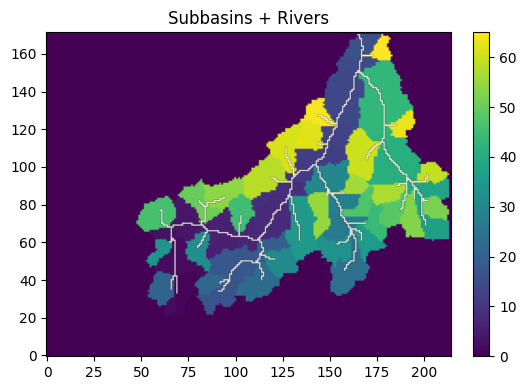

In [17]:
#plot the resulting subbasins and rivers
temp = subbasin['RiverMask'].copy()
temp[temp == 0] = np.nan

fig, ax = plt.subplots(figsize=(6, 4))
# Base layer
im0 = ax.imshow(subbasin['subbasins'],
                cmap='viridis',
                origin='lower')
# Overlay (rivers)
im1 = ax.imshow(temp * 2,
                cmap='Reds',      # different colormap helps visibility
                origin='lower',
                alpha=0.8)        # transparency like add=TRUE overlay
ax.set_title("Subbasins + Rivers")
plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [18]:
slopes_uw = slope_calc_upwind(
    dem=trav_hs["dem"].copy(),
    mask=watershed_mask.copy(),
    direction=trav_hs["direction"].copy(),
    dx=dx,
    dy=dy,
    secondary_th=scale,
    maxslope=maxslope,
    minslope=minslope,
    river_method=riv_method,
    rivermask=subbasin["RiverMask"].copy(),
    subbasins=subbasin["subbasins"].copy(),
)

upwinding slopes
Limiting slopes to maximum absolute value of 0.5
Limiting the ratio of secondary to primary slopes 0.1
River Method 3: assigning average river slope to river cells by watershed
Scaling secondary slopes along river mask to 0 * primary slope
After processing: 0 Flat cells left
Limiting slopes to minimum 1e-05


### Option 2b: Alternate more advanced approach: 
Define a river mask separate from the subbasin river mask and use this for the slope calculations. If you do this the average slopes will still be calculated
by subbasin using the sub_th, but you can apply those average sloeps to more river cells by setting a lower threshold here. This is the 'riv_th' set at the top
if you set riv_th=sub_th at the top this will have the same effect as just running the slope calc with the subbasin['RiverMask']

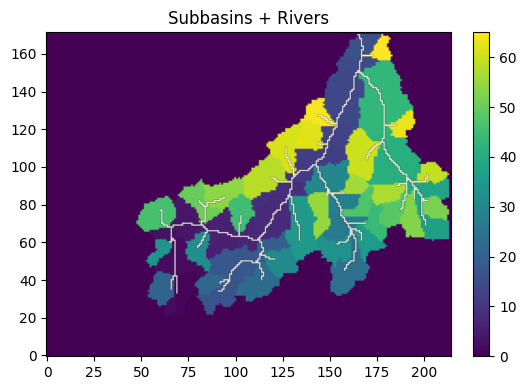

In [19]:
rivers = np.zeros_like(area)
rivers[area < riv_th] = 0
rivers[area >= riv_th] = 1

# plot the subbasins with the new river mask to check that the threshold is good
temp = rivers.copy()
temp[temp == 0] = np.nan

fig, ax = plt.subplots(figsize=(6, 4))
# Base layer
im0 = ax.imshow(subbasin['subbasins'],
                cmap='viridis',
                origin='lower')
# Overlay (rivers)
im1 = ax.imshow(temp * 2,
                cmap='Reds',      # different colormap helps visibility
                origin='lower',
                alpha=0.8)        # transparency like add=TRUE overlay
ax.set_title("Subbasins + Rivers")
plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [20]:
slopes_uw = slope_calc_upwind(
    dem=trav_hs["dem"].copy(),
    mask=watershed_mask.copy(),
    direction=trav_hs["direction"].copy(),
    dx=dx,
    dy=dy,
    secondary_th=0.1,
    maxslope=maxslope,
    minslope=minslope,
    river_method=riv_method,
    rivermask=rivers,
    subbasins=subbasin["subbasins"].copy(),
)

upwinding slopes
Limiting slopes to maximum absolute value of 0.5
Limiting the ratio of secondary to primary slopes 0.1
River Method 3: assigning average river slope to river cells by watershed
Scaling secondary slopes along river mask to 0 * primary slope
After processing: 0 Flat cells left
Limiting slopes to minimum 1e-05


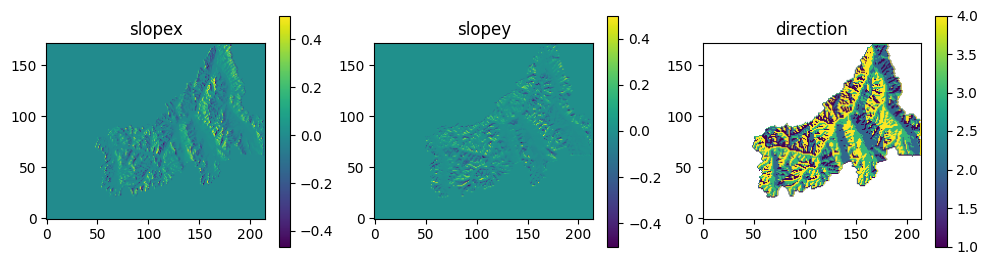

In [21]:
#Look at the slopes and directions
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
im0 = axes[0].imshow(slopes_uw['slopex'], cmap='viridis', origin='lower')
axes[0].set_title("slopex")
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(slopes_uw['slopey'], cmap='viridis', origin='lower')
axes[1].set_title("slopey")
plt.colorbar(im1, ax=axes[1])
im2 = axes[2].imshow(slopes_uw['direction'], cmap='viridis', origin='lower')
axes[2].set_title("direction")
plt.colorbar(im2, ax=axes[2])
plt.show()

In [22]:
# Calculate the drainage area
area = drainage_area(
    slopes_uw["direction"],
    mask=watershed_mask,
    printflag=False,
)

In [23]:
# Save slope data as PFB files:
write_pfb("slopex.pfb", slopes_uw["slopex"])
write_pfb("slopey.pfb", slopes_uw["slopey"])